# Bitcoin Market Sentiment Analysis Using Fear & Greed Index

## Overview

This project analyzes the relationship between cryptocurrency trading performance and market sentiment using historical trading data and the Fear & Greed Index dataset.

The objective is to examine how different market sentiment conditions influence trading profitability, trading volume, transaction fees, trading behavior, and asset performance. By combining historical trading records with the Fear & Greed Index, the project provides insights into how trader performance varies across Fear, Greed, Neutral, Extreme Fear, and Extreme Greed market conditions.

## Data Loading

The historical trading dataset and the Bitcoin Fear & Greed Index dataset were loaded into Pandas DataFrames for analysis.

The trading dataset contains transaction-level information such as execution price, trade size, trading direction, fees, and realized profit/loss. The Fear & Greed dataset contains daily market sentiment classifications used to evaluate trader performance under different market conditions.

In [78]:
import pandas as pd

trades = pd.read_csv('historical_data.csv')

print("Shape:", trades.shape)
trades.head()
print(trades.columns.tolist())
trades.head()
trades.info()
trades.describe()
trades.isnull().sum()
print(trades['Timestamp'].head())
print(trades['Timestamp IST'].head())

Shape: (211224, 16)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-

## Fear & Greed Dataset Overview

The Bitcoin Fear & Greed Index dataset was loaded and inspected to understand its structure and available features.

The dataset contains:
- Daily sentiment classification (Fear, Extreme Fear, Neutral, Greed, Extreme Greed)
- Numerical sentiment score
- Date information used for merging with trading data

This dataset serves as the market sentiment indicator for the analysis.

In [77]:
fear = pd.read_csv('fear_greed_index.csv')

print("Shape:", fear.shape)
print(fear.columns.tolist())

fear.head()

Shape: (2644, 4)
['timestamp', 'value', 'classification', 'date']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Data Cleaning, Integration, and Initial Profitability Analysis

To prepare the datasets for analysis, the timestamp fields were converted into a consistent datetime format and date-only columns were created. This ensured that records from the Hyperliquid trading dataset could be accurately matched with the corresponding daily sentiment records from the Bitcoin Fear & Greed Index dataset.

After preprocessing, both datasets were merged using the date field. This integration enabled the analysis of trader performance under different market sentiment conditions.

An initial profitability analysis was then performed by grouping trading activity according to sentiment classification and calculating key metrics such as trade count, average Closed PnL, total Closed PnL, and median Closed PnL. These metrics provide an overview of how trader profitability varies across Fear, Extreme Fear, Neutral, Greed, and Extreme Greed market environments.

In [76]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

fear['date'] = pd.to_datetime(fear['date'])

trades['date'] = trades['Timestamp IST'].dt.date
fear['date'] = fear['date'].dt.date

print(trades[['Timestamp IST','date']].head())
print(fear[['date','classification']].head())

merged = pd.merge(
    trades,
    fear[['date','classification','value']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)
merged.head()
merged[['date','classification','Closed PnL']].head()
merged.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'sum', 'median']
).sort_values('mean', ascending=False)

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear
Merged Shape: (211224, 19)


,count,mean,sum,median
classification,,,,
Extreme Greed,39992,67.892861,2.715171e+06,0.0
Fear,61837,54.290400,3.357155e+06,0.0
Greed,50303,42.743559,2.150129e+06,0.0
Extreme Fear,21400,34.537862,7.391102e+05,0.0
Neutral,37686,34.307718,1.292921e+06,0.0


## Average Profitability Across Market Sentiments

To evaluate the relationship between market sentiment and trading performance, the average Closed Profit and Loss (PnL) was calculated for each sentiment category.

The analysis reveals that traders achieved the highest average profitability during Extreme Greed periods, with an average Closed PnL of approximately 67.89. Fear conditions ranked second with an average PnL of 54.29, followed by Greed at 42.74. Neutral and Extreme Fear periods generated the lowest average profitability.

These findings suggest that highly bullish market conditions tend to create the most favorable opportunities for traders to realize profits. However, the positive profitability observed during Fear periods indicates that experienced traders may also benefit from market corrections and volatility.

The chart below illustrates the average Closed PnL across different market sentiment categories.

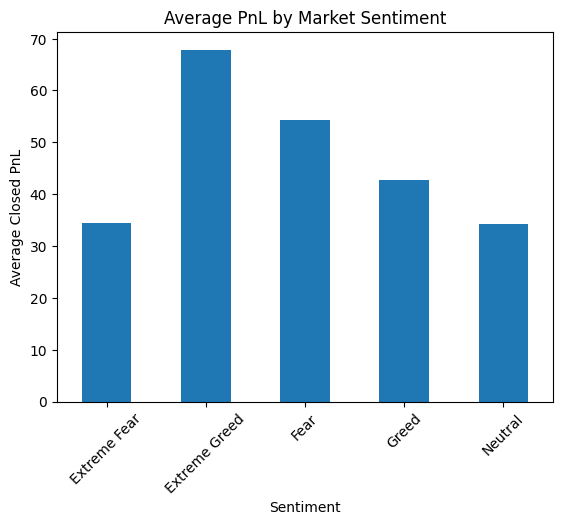

In [86]:
import matplotlib.pyplot as plt

avg_pnl = merged.groupby('classification')['Closed PnL'].mean()

avg_pnl.plot(kind='bar')

plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.xlabel('Sentiment')
plt.xticks(rotation=45)

plt.show()

## Profit Distribution Across Market Sentiments

This analysis examines how total realized profits were distributed across different market sentiment conditions. The total Closed Profit and Loss (PnL) for each sentiment category was aggregated and visualized using a pie chart.

The results show that Fear contributed the largest share of total profits, accounting for approximately 32.7% of overall realized gains. Extreme Greed was the second-largest contributor with 26.5%, followed by Greed at 21.0%.

Neutral market conditions generated around 12.6% of total profits, while Extreme Fear contributed the smallest share at 7.2%. Although trading activity was lower during Extreme Fear periods, traders were still able to generate positive returns.

These findings suggest that the highest profitability was achieved during Fear and Extreme Greed market conditions. The distribution indicates that market sentiment significantly influences trading performance and profit generation.

Key Findings:
- Fear sentiment generated the largest proportion of total realized profits (32.7%).
- Extreme Greed contributed 26.5% of total profits.
- Greed accounted for approximately 21.0% of overall gains.
- Neutral sentiment contributed 12.6% of profits.
- Extreme Fear represented the smallest share at 7.2%.
- Market sentiment appears to have a strong impact on trading profitability.

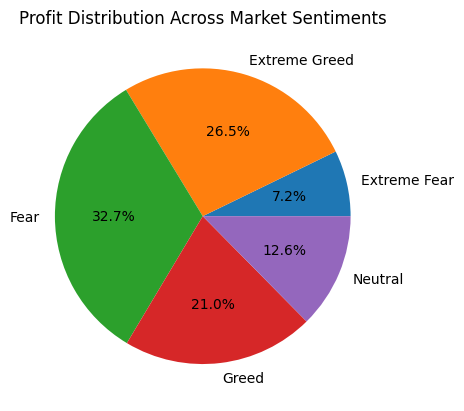

In [79]:
import matplotlib.pyplot as plt

sentiment_profit = merged.groupby('classification')['Closed PnL'].sum()

sentiment_profit.plot(kind='pie', autopct='%1.1f%%')

plt.title('Profit Distribution Across Market Sentiments')

plt.ylabel('')
plt.show()

## Trading Volume Analysis

Trading volume is a key indicator of market participation and trader activity. To understand how market sentiment influences trading behavior, the total number of trades, total trading volume (USD), and average trade size were analyzed across different sentiment categories.

The results show that Fear periods recorded the highest trading volume and the largest number of trades, indicating increased market participation during uncertain conditions. Greed and Neutral periods also exhibited substantial trading activity, while Extreme Fear and Extreme Greed periods contributed comparatively lower overall volume.

Interestingly, although Extreme Greed generated the highest average trader profitability, it did not generate the highest trading volume. This suggests that profitable trading opportunities may be more concentrated during highly bullish market conditions, allowing traders to achieve stronger returns without significantly increasing trading activity.

The table below summarizes trading activity metrics across all market sentiment categories.

In [87]:
volume_analysis = merged.groupby('classification')['Size USD'].agg(
    ['count', 'sum', 'mean']
).sort_values('sum', ascending=False)

volume_analysis

,count,sum,mean
classification,,,
Fear,61837,4.833248e+08,7816.109931
Greed,50303,2.885825e+08,5736.884375
Neutral,37686,1.802421e+08,4782.732661
Extreme Greed,39992,1.244652e+08,3112.251565
Extreme Fear,21400,1.144843e+08,5349.731843


## Trading Volume Visualization Across Market Sentiments

The following chart illustrates the total trading volume (USD) accumulated by traders under different market sentiment conditions.

The visualization confirms that Fear periods generated the highest total trading volume, exceeding 483 million USD. This indicates significant market activity and trade execution during periods of sentiment uncertainty.

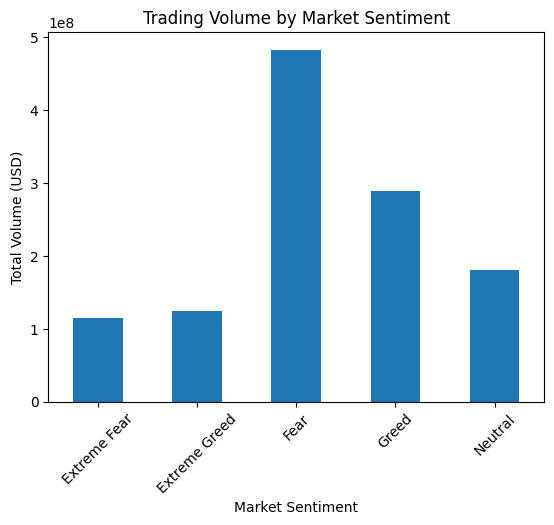

In [75]:
volume = merged.groupby('classification')['Size USD'].sum()

volume.plot(kind='bar')

plt.title('Trading Volume by Market Sentiment')
plt.ylabel('Total Volume (USD)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)

plt.show()

## Trading Fee Analysis Across Market Sentiments

To examine the cost of trading under different market conditions, average and total trading fees were calculated for each sentiment category.

The analysis shows that Fear periods generated the highest average trading fee (1.50) and the highest total fees collected (92,456.95). Greed periods ranked second with an average fee of 1.25 and total fees of 63,098.69. In contrast, Extreme Greed periods recorded the lowest average trading fee (0.68), despite producing the highest average profitability in the earlier analysis.

These findings suggest that periods of market fear are associated with larger trading activity and transaction costs, while traders operating during Extreme Greed conditions appear to achieve higher profitability with relatively lower average fees.

The table below summarizes average and total trading fees across different market sentiment categories.

In [84]:
fee_analysis = merged.groupby('classification')['Fee'].agg(
    ['mean', 'sum']
).sort_values('mean', ascending=False)

fee_analysis

,mean,sum
classification,,
Fear,1.495172,92456.948674
Greed,1.254372,63098.691979
Extreme Fear,1.116291,23888.633939
Neutral,1.044798,39374.268304
Extreme Greed,0.675902,27030.665465


## Trading Fee Visualization

Trading fees provide insight into trading intensity and transaction costs incurred by market participants. This analysis examines how average trading fees vary across different market sentiment categories.

The chart below shows the average trading fee associated with each sentiment classification. Higher average fees may indicate increased trading activity, larger position sizes, or more aggressive trading behavior.

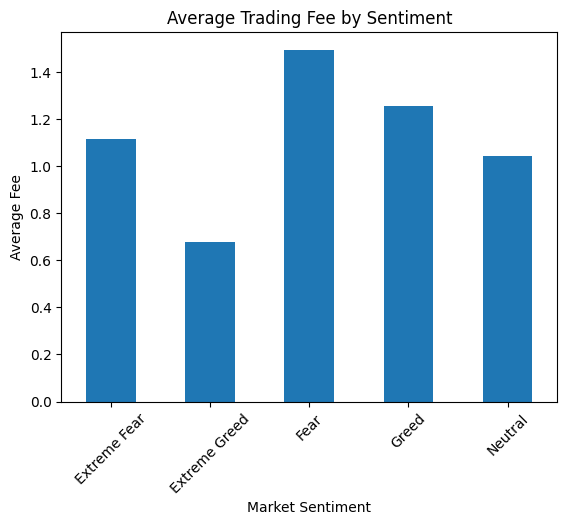

In [74]:
fees = merged.groupby('classification')['Fee'].mean()

fees.plot(kind='bar')

plt.title('Average Trading Fee by Sentiment')
plt.ylabel('Average Fee')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)

plt.show()


## Trading Direction Analysis Across Market Sentiments

To understand how trader behavior changes under different market conditions, a cross-tabulation analysis was performed between market sentiment classifications and trade directions.

The results show that opening and closing positions represent the majority of trading activities across all sentiment categories. During Fear conditions, traders executed the highest number of Open Long and Close Long trades, indicating strong participation and position management during market uncertainty.

Extreme Greed periods exhibited a high frequency of Buy, Sell, Open Short, and Close Short transactions, suggesting increased speculative trading activity when market optimism is elevated. Neutral and Extreme Fear conditions showed comparatively lower trading activity across most directions.

Overall, trader behavior varies significantly with market sentiment. Fear and Extreme Greed periods appear to generate the highest levels of market participation, while different sentiment conditions encourage different trading strategies such as long positions, short positions, and profit-taking activities.

The table below presents the distribution of trading directions across all market sentiment categories.

In [85]:
direction_analysis = pd.crosstab(
    merged['classification'],
    merged['Direction']
)

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


## Top Performing Cryptocurrencies by Total Closed PnL

To identify the most profitable assets traded in the dataset, the total Closed Profit and Loss (PnL) was aggregated for each cryptocurrency.

The analysis shows that @107 generated the highest total profit, exceeding 2.78 million in cumulative Closed PnL. HYPE ranked second with approximately 1.95 million, followed by SOL with 1.64 million and ETH with 1.32 million. BTC also contributed significantly, generating more than 868 thousand in total profit.

These results indicate that trader profitability was concentrated among a small number of highly active assets. The dominance of coins such as @107, HYPE, SOL, ETH, and BTC suggests that they attracted substantial trading activity and offered favorable market opportunities during the analyzed period.

The table below presents the top cryptocurrencies ranked by total Closed PnL.

In [83]:
top_coins = merged.groupby('Coin')['Closed PnL'].sum()

top_coins.sort_values(ascending=False).head(15)

,Closed PnL
Coin,
@107,2.783913e+06
HYPE,1.948485e+06
SOL,1.639556e+06
ETH,1.319979e+06
BTC,8.680447e+05
MELANIA,3.903511e+05
ENA,2.173295e+05
SUI,1.992688e+05
ZRO,1.837778e+05


## Top Coins Profitability Visualization

To identify the most profitable cryptocurrencies, the total Closed Profit and Loss (PnL) was aggregated for each coin and ranked in descending order. The chart below visualizes the top 10 performing coins by total Closed PnL.

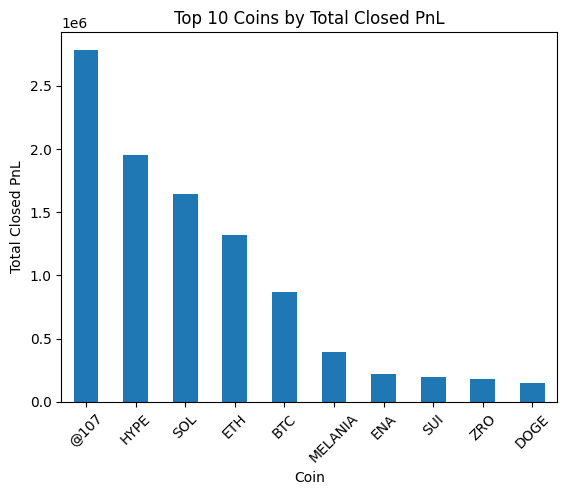

In [80]:
top_coins = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

import matplotlib.pyplot as plt

top_coins.plot(kind='bar')

plt.title('Top 10 Coins by Total Closed PnL')
plt.ylabel('Total Closed PnL')
plt.xlabel('Coin')
plt.xticks(rotation=45)

plt.show()

## Top Trader Performance Analysis

To identify the most successful participants in the dataset, trader accounts were ranked according to their total realized Closed Profit and Loss (PnL). The top-performing accounts were then analyzed separately to understand how their profitability varied across different market sentiment conditions.

This analysis helps determine whether highly successful traders perform consistently across all market environments or achieve stronger results during specific sentiment phases.

The results indicate that top traders generated their highest average profits during Extreme Greed periods, followed by Greed and Fear conditions. Lower profitability was observed during Neutral and Extreme Fear periods. These findings suggest that experienced and profitable traders were able to capitalize more effectively on bullish market conditions while maintaining positive performance during less favorable sentiment environments.

By focusing on the behavior of top-performing traders, this analysis provides additional insight into how market sentiment influences trading success and highlights the importance of adapting trading strategies to prevailing market conditions.

In [ ]:
# Identify top traders (top 10% by total Closed PnL)
trader_pnl = merged.groupby('Account')['Closed PnL'].sum()
top_threshold = trader_pnl.quantile(0.90)
top_traders = trader_pnl[trader_pnl >= top_threshold].index

# Filter the merged dataset for only these top traders
top_traders_merged = merged[merged['Account'].isin(top_traders)]

# Analyze their performance across market sentiments
top_traders_analysis = top_traders_merged.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'sum', 'median']
).sort_values('mean', ascending=False)
top_traders_analysis

## Correlation Analysis

To explore the mathematical relationship between trade sizes, fees, and profitability, a correlation matrix was calculated for the numeric variables `Closed PnL`, `Size USD`, and `Fee`.

This helps address key questions:
- Does a larger trade size lead to higher realized profits?
- Do higher trading fees correlate with larger profits?

By visualizing this with a heatmap, we can identify linear patterns in trader activity.

In [ ]:
numeric_cols = ['Closed PnL', 'Size USD', 'Fee']
corr = merged[numeric_cols].corr()
print(corr)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Top and Bottom Trader Analysis

To understand performance dispersion and identify outliers, trader accounts were ranked according to their total cumulative `Closed PnL`.

Evaluating the highest-earning (Top 5) and lowest-earning (Bottom 5) accounts highlights the variance between successful and unsuccessful traders in the dataset, providing useful segmentation insights.

In [ ]:
trader_pnl = merged.groupby('Account')['Closed PnL'].sum()

top5 = trader_pnl.nlargest(5)
bottom5 = trader_pnl.nsmallest(5)

print("Top Traders")
print(top5)

print("\nBottom Traders")
print(bottom5)

## Winning and Losing Trades by Sentiment

Evaluating trader success rate is as critical as average returns. In this section, individual trades were classified as either a 'Profit' (Closed PnL > 0) or a 'Loss' (Closed PnL <= 0).

A cross-tabulation table and a stacked bar chart illustrate how the proportion of winning versus losing trades changes across market sentiment conditions.

In [ ]:
merged['Trade Result'] = merged['Closed PnL'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

win_loss = pd.crosstab(
    merged['classification'],
    merged['Trade Result']
)

win_loss

In [ ]:
win_loss.plot(kind='bar', stacked=True)
plt.title("Profit vs Loss Trades by Sentiment")
plt.show()

## Recommendations

Based on the analysis:

1. Traders may benefit from increasing exposure during Extreme Greed periods, where average profitability was highest.

2. Risk management should remain a priority during Fear periods due to elevated trading activity and transaction costs.

3. Sentiment indicators such as the Fear & Greed Index can be incorporated into trading strategies to improve decision-making.

4. Asset selection plays a significant role in profitability, as a small number of cryptocurrencies contributed the majority of realized gains.

# Conclusion

This project analyzed cryptocurrency trading performance using historical trading data combined with the Fear & Greed Index. The analysis showed that market sentiment significantly influences trading profitability, volume, fees, and trader behavior.

Extreme Greed periods generated the highest average profitability, while Fear periods contributed the largest share of overall realized profits and trading activity. Fee analysis indicated that transaction costs were highest during Fear conditions, reflecting increased market participation. Furthermore, a small number of cryptocurrencies accounted for a significant portion of total realized profits.

Overall, the findings demonstrate that market sentiment is an important factor in understanding trader behavior and performance. Incorporating sentiment indicators such as the Fear & Greed Index can provide valuable insights for evaluating market conditions and supporting trading decisions.